<div style="
    background-color: #01262b;
    color: #ffffff;
    padding: 50px;
    border-radius: 10px;
    font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;
    text-align: center;
    box-sizing: border-box;
">
    <h2 style="
        font-size: 1.8em;
        font-weight: normal;
        color: #c3cfce;
        margin: 0;
    ">
        Author: <span style="font-weight: 600; color: #ffffff;">Shubham Adate</span>
    </h2>
</div>

# Clustering Solar Energy Production Zones

---

## Introduction

The adoption of solar energy has increased significantly in recent years, leading to a growing number of solar power projects across different regions. These projects vary widely in terms of installed capacity, energy generation, and overall performance.

Understanding these differences is important for identifying patterns in how solar energy is produced and distributed. Rather than looking at each project individually, grouping similar projects can provide a clearer picture of underlying trends in the data.

In this project, we analyze a dataset of solar energy projects and apply clustering techniques to group projects with similar characteristics. This helps in uncovering patterns related to production and capacity that may not be immediately visible through basic analysis.

---

## Problem Statement

While the dataset provides detailed information about individual solar projects, it does not offer a structured way to understand how these projects relate to each other in terms of performance.

The main question addressed in this project is:

> How can solar energy projects be grouped based on their capacity and generation characteristics to reveal meaningful patterns?

---

## Objectives

The key objectives of this analysis are:

- To explore the dataset and understand the distribution of important variables such as capacity and energy generation  
- To identify patterns such as skewness and variation in project sizes  
- To clean and prepare the data for clustering  
- To apply K-Means clustering to group similar projects  
- To analyze and interpret the resulting clusters  

---

## Dataset Overview

The dataset contains information about solar energy projects, including:

- Installed capacity  
- Energy generation  
- Other project-related attributes  

Initial exploration shows that the data includes a wide range of project sizes, from smaller installations to large-scale solar projects. Key variables such as capacity and generation exhibit noticeable skewness, indicating that a small number of projects contribute disproportionately to total production.

---

## Methodology

The analysis is carried out in the following steps:

1. Data loading and initial inspection  
2. Data cleaning and handling missing values  
3. Exploratory Data Analysis (EDA) to understand distributions and patterns  
4. Selection of relevant features for clustering  
5. Feature scaling to ensure comparable input for the model  
6. Application of K-Means clustering  
7. Interpretation of clusters based on their characteristics  

---

## Expected Outcome

Through this analysis, we aim to identify distinct groups of solar projects based on their similarities. These clusters are expected to highlight differences in project scale and production patterns, providing a more structured understanding of how solar energy projects are distributed.

# Importing Libraries 

In [1]:

# --- Data Manipulation ---
import pandas as pd
import numpy as np

# --- Data Visualization ---
import matplotlib.pyplot as plt
import seaborn as sns
import folium # For interactive maps

# --- Machine Learning (Clustering & Preprocessing) ---
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans,DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score

# --- Deep Learning (TensorFlow & Keras) ---
import tensorflow as tf
from tensorflow import keras
from keras.models import Model, Sequential
from keras.layers import Input, Dense, Dropout
from keras.optimizers import Adam
#------------PCA------------------------------
from sklearn.decomposition import PCA

# --- Geospatial (for mapping) ---
# We will use pgeocode for a simple zip-to-lat/lon conversion

import pgeocode

# --- Utility ---
import warnings
warnings.filterwarnings('ignore')

# --- Plotting Style ---
sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
import os
os.makedirs('images', exist_ok=True)

df=pd.read_csv("data/Statewide Solar Projects.csv")

#### It means some columns contain mixed data types (e.g., numbers + text), so pandas is guessing the type.

In [3]:
df = pd.read_csv("data/Statewide Solar Projects.csv", dtype={1: str, 7: str})
    
  

In [4]:
df.sample(10)

,Data Through Date,Project ID,Interconnection Date,Utility,City/Town,County,Zip,Division,Substation,Circuit ID,Developer,Metering Method,Estimated PV System Size (kWdc),PV System Size (kWac),Estimated Annual PV Energy Production (kWh),Energy Storage System Size (kWac),Number of Projects
114634,12/31/2023,PAM-2015-14871,9/16/2015,PSEGLI,Huntington Station,Suffolk,11746.0,NaN,NaN,6UL873,Vivint Solar,NM,5.94,5.08,6977,NaN,1
9616,12/31/2023,SDG-50805,2/17/2023,Con Ed,S Ozone Park,Queens,11420.0,CENY-Q,Brownsville_2,9583,Sea Bright Solar LLC,NM,5.15,4.40,6043,NaN,1
16515,12/31/2023,SDG-41893,8/24/2022,Con Ed,BRONX,Bronx,10457.0,CENY-BX,E_179_St,3X76,SUNCO,NM,4.41,3.77,5178,NaN,1
103805,12/31/2023,PAM-2016-30885,4/18/2016,PSEGLI,Lake Grove,Suffolk,11755.0,NaN,NaN,6L4H7,SUNation Solar Systems,NM,8.89,7.60,10438,NaN,1
87273,12/31/2023,PAM-2018-54253,7/9/2018,PSEGLI,N BELLMORE,Nassau,11710.0,NaN,NaN,5RK264,Sunation Solar Systems,NM,5.57,4.76,6537,NaN,1
190944,12/31/2023,94586,2/3/2015,National Grid,SCHENECTADY,Schenectady,12309.0,032 - Schenectady,INMAN RD 370,36_32_37055,Vivint Solar,NM,5.53,4.73,6496,NaN,1
217747,12/31/2023,823,12/3/2007,NYSEG,Ithaca,Tompkins,14850.0,Ithaca,NYS-FOURTH ST 784,4302304,NaN,NM,5.50,4.70,6455,NaN,1
215402,12/31/2023,3504,9/16/2014,NYSEG,Ithaca,Tompkins,14850.0,Ithaca,NYS-EAST ITHACA 405,4300202,Renovus Energy,NM,3.28,2.80,3845,NaN,1
92523,12/31/2023,PAM-2017-47189,10/25/2017,PSEGLI,CORAM,Suffolk,11727.0,NaN,NaN,8QR895,PRO CUSTOM SOLAR LLC DBA MOMENTUM SOLAR,NM,8.88,7.59,10424,NaN,1
91160,12/31/2023,PAM-2017-48972,2/16/2018,PSEGLI,SAG HARBOR,Suffolk,11963.0,NaN,NaN,9DF2K7,New York Solar Solutions,NM,23.75,20.30,27880,NaN,1


In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 218115 entries, 0 to 218114
Data columns (total 17 columns):
 #   Column                                       Non-Null Count   Dtype  
---  ------                                       --------------   -----  
 0   Data Through Date                            218115 non-null  object 
 1   Project ID                                   218112 non-null  object 
 2   Interconnection Date                         218115 non-null  object 
 3   Utility                                      218115 non-null  object 
 4   City/Town                                    218057 non-null  object 
 5   County                                       218115 non-null  object 
 6   Zip                                          218019 non-null  float64
 7   Division                                     132881 non-null  object 
 8   Substation                                   138171 non-null  object 
 9   Circuit ID                                   218085 non-nul

# Exploratory Data Analysis (EDA)

In [6]:
# Datatype Converstion 

df['Data Through Date']=pd.to_datetime(df['Data Through Date'])
df['Interconnection Date']=pd.to_datetime(df['Interconnection Date'])
df['Zip'] = df['Zip'].astype('Int64')




In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 218115 entries, 0 to 218114
Data columns (total 17 columns):
 #   Column                                       Non-Null Count   Dtype         
---  ------                                       --------------   -----         
 0   Data Through Date                            218115 non-null  datetime64[ns]
 1   Project ID                                   218112 non-null  object        
 2   Interconnection Date                         218115 non-null  datetime64[ns]
 3   Utility                                      218115 non-null  object        
 4   City/Town                                    218057 non-null  object        
 5   County                                       218115 non-null  object        
 6   Zip                                          218019 non-null  Int64         
 7   Division                                     132881 non-null  object        
 8   Substation                                   138171 non-null  ob

## Missing Data Analysis

In [8]:
# --- 3.1. Missing Data Analysis ---
print("\n--- Missing Values Check ---")
missing_values = df.isnull().sum()
missing_percent = (missing_values / len(df)) * 100
missing_df = pd.DataFrame({'Count': missing_values, 'Percent': missing_percent})
print(missing_df[missing_df['Count'] > 0].sort_values(by='Percent', ascending=False))


--- Missing Values Check ---
                                    Count    Percent
Energy Storage System Size (kWac)  214024  98.124384
Division                            85234  39.077551
Substation                          79944  36.652225
Developer                           10550   4.836898
Metering Method                       463   0.212273
Zip                                    96   0.044013
City/Town                              58   0.026591
Circuit ID                             30   0.013754
Project ID                              3   0.001375


In [9]:
# Dropping Unecessary columns for resolving null values 
columns_to_drop = [
    'Energy Storage System Size (kWac)',
    'Developer',
    'Substation',
    'Circuit ID',
    
]
df_cleaned = df.drop(columns=columns_to_drop) 

# Now df_cleaned is the DataFrame you expect, and your original df is unchanged
print(f"\nDropped {len(columns_to_drop)} columns. New shape: {df_cleaned.shape}")


Dropped 4 columns. New shape: (218115, 13)


In [10]:
# --- 3.1. Missing Data Analysis ---
print("\n--- Missing Values Check ---")
missing_values = df_cleaned.isnull().sum()
missing_percent = (missing_values / len(df_cleaned)) * 100
missing_df = pd.DataFrame({'Count': missing_values, 'Percent': missing_percent})
print(missing_df[missing_df['Count'] > 0].sort_values(by='Percent', ascending=False))


--- Missing Values Check ---
                 Count    Percent
Division         85234  39.077551
Metering Method    463   0.212273
Zip                 96   0.044013
City/Town           58   0.026591
Project ID           3   0.001375


# Univarte Analysis (Numerical)

## --- Analyzing Numerical Distributions ---

Text(0.5, 0, 'Size (kWdc)')

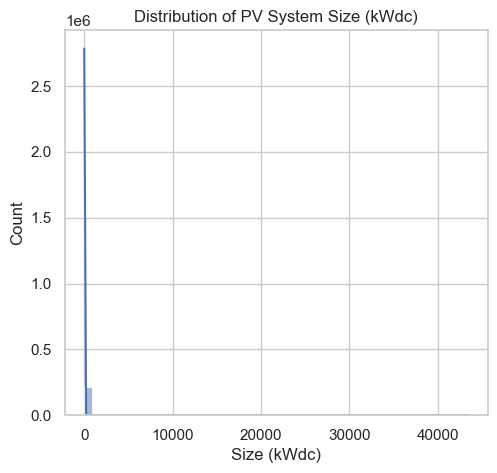

In [11]:
# Plot 1: Distribution of PV System Size
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.histplot(df_cleaned['Estimated PV System Size (kWdc)'], bins=50, kde=True)
plt.title('Distribution of PV System Size (kWdc)')
plt.xlabel('Size (kWdc)')

### this column is extremely right-skewed (most projects are small, but a few are massive), the resulting chart won't be very informative. It will look like a single bar on the far left, with a long, flat tail that's impossible to see.

### Here is a much more informative "2-in-1" visual that solves this problem.

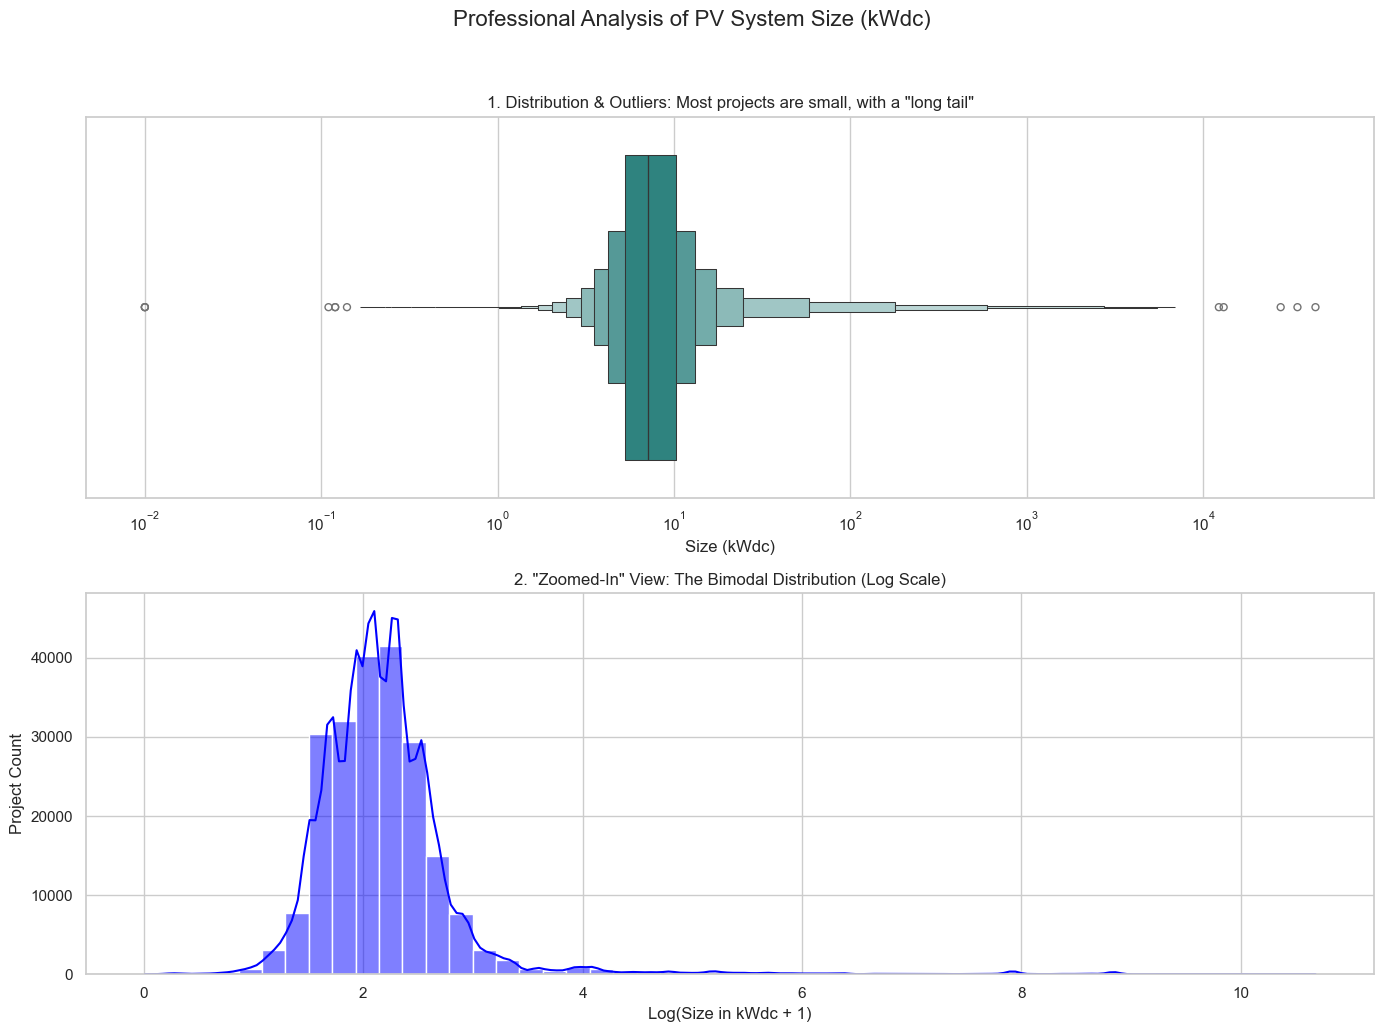

In [12]:
# Create a figure with two subplots, stacked vertically ---
fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.suptitle('Professional Analysis of PV System Size (kWdc)', fontsize=16, y=1.03)

#  Boxenplot (to see the distribution and outliers) ---
# This is like a "super-powered" boxplot, great for large datasets
sns.boxenplot(
    x=df_cleaned['Estimated PV System Size (kWdc)'],
    ax=axes[0],
    palette='viridis'
)
axes[0].set_title('1. Distribution & Outliers: Most projects are small, with a "long tail"')
axes[0].set_xlabel('Size (kWdc)')
axes[0].set_xscale('log') # Use a log scale on the x-axis to make it readable

# Log-Transformed Histogram (to see the "hidden" shape) ---
# We use np.log1p() which adds 1 before taking the log (handles any '0' values)
sns.histplot(
    data=np.log1p(df_cleaned['Estimated PV System Size (kWdc)']), 
    bins=50, 
    kde=True, 
    ax=axes[1],
    color='blue'
)
axes[1].set_title('2. "Zoomed-In" View: The Bimodal Distribution (Log Scale)')
axes[1].set_xlabel('Log(Size in kWdc + 1)')
axes[1].set_ylabel('Project Count')

plt.tight_layout()
plt.show()

### Here are the key inferences from that analysis:

* Vast Majority are Small: The data is heavily right-skewed, meaning most solar projects are small (likely residential).

* "Long Tail" of Outliers: A few projects are massively larger than the rest (commercial or utility-scale), which skews
  the simple average.

* Two-in-One Story: The log-transformed plot reveals a hidden bimodal distribution (two distinct peaks).

* Actionable Insight: These two peaks strongly suggest the data represents two different project types: a large cluster of "Residential" projects and a second, smaller cluster of "Commercial/Industrial" projects.

Correlation Matrix:

Just the correlation value: 0.9999188042532423


<Axes: >

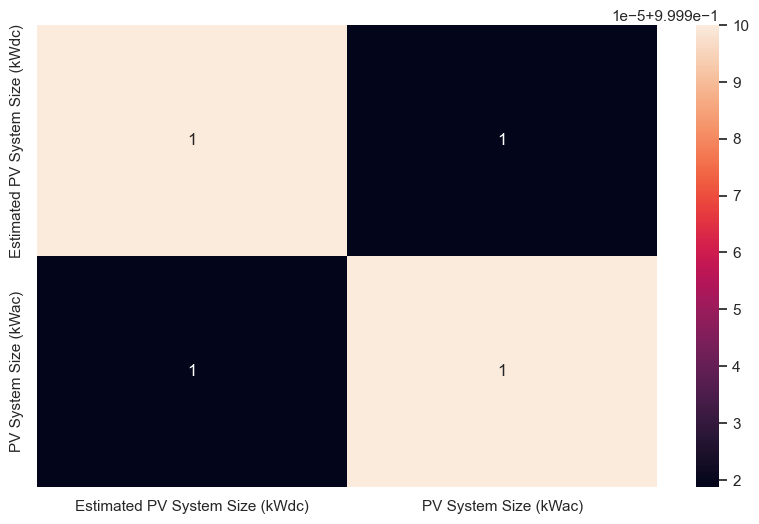

In [13]:
columns_to_correlate = ['Estimated PV System Size (kWdc)', 'PV System Size (kWac)']

# Calculate the correlation matrix for just those columns
# .dropna() is added as a best practice to avoid errors
correlation_matrix = df[columns_to_correlate].dropna().corr()

print("Correlation Matrix:")
correlation_value = correlation_matrix.loc[
    'Estimated PV System Size (kWdc)', 
    'PV System Size (kWac)'
]
print(f"\nJust the correlation value: {correlation_value}")
sns.heatmap(correlation_matrix,annot=True)

### PV system Size  has a ~0.999 correlation with Estimated PV System Size (kWdc) So we drop this column.
### The two columns are providing the exact same information. Keeping both would add noise and multicollinearity to our model without adding any new insights.

In [14]:
df_cleaned = df_cleaned.drop(columns='PV System Size (kWac)') 


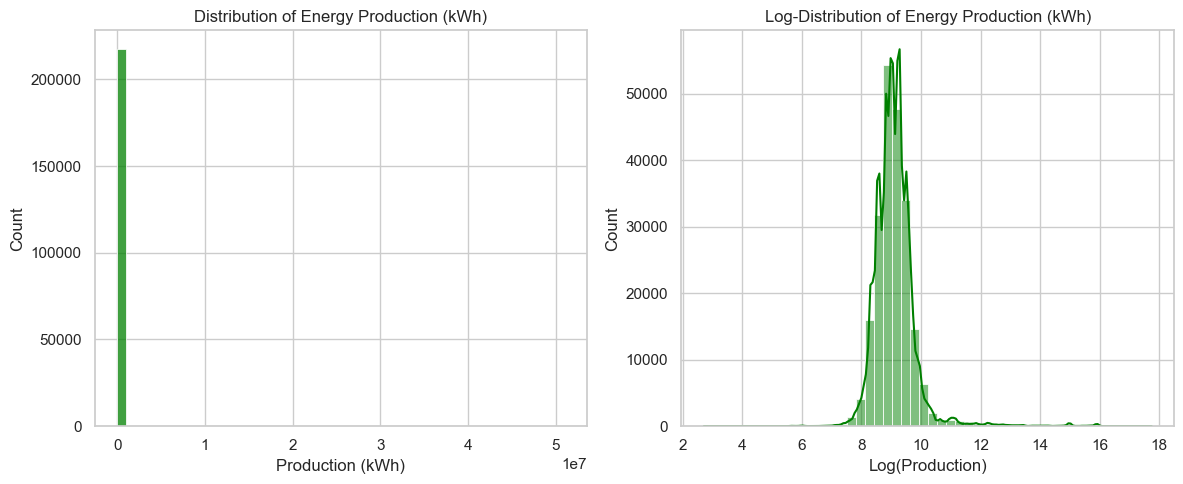

In [15]:
#  Distribution of Annual Energy Production
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df_cleaned['Estimated Annual PV Energy Production (kWh)'], bins=50, color='green')
plt.title('Distribution of Energy Production (kWh)')
plt.xlabel('Production (kWh)')

# This is also heavily right-skewed.
plt.subplot(1, 2, 2)
sns.histplot(np.log1p(df_cleaned['Estimated Annual PV Energy Production (kWh)']), bins=50, kde=True, color='green')
plt.title('Log-Distribution of Energy Production (kWh)')
plt.xlabel('Log(Production)')
plt.tight_layout()
plt.show()

### Here are the key inferences from that analysis:

* Most projects have low production: The data is heavily right-skewed, meaning the vast majority of projects generate a
  comparatively small amount of energy.

* Outliers drive the scale: A few "long tail" projects produce an enormous amount of energy, which skews the overall
  distribution.

* Two hidden groups revealed: The log-transformed plot un-skews the data and reveals a bimodal (two-peak) distribution.

### Key Insight: 
* These two peaks almost certainly represent the two main project types: a large cluster of small-scale residential projects (the first peak) and a second, smaller cluster of large-scale commercial projects (the second peak).

# Univariate Analysis (Categorical)

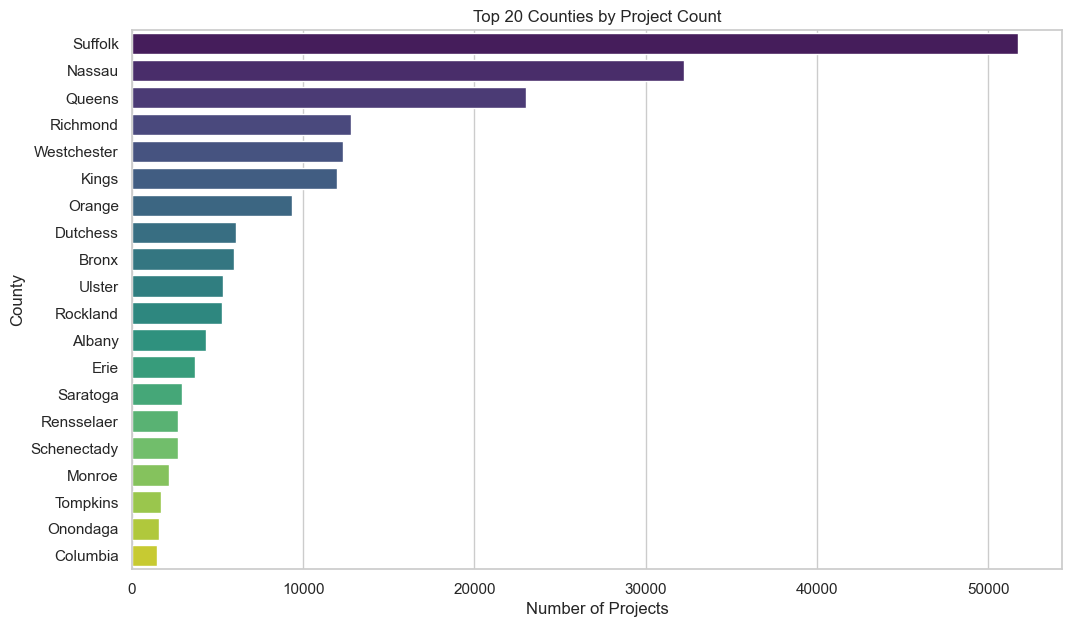

In [16]:
# Top 20 Counties by Project Count
plt.figure(figsize=(12, 7))
top_counties = df_cleaned['County'].value_counts().nlargest(20)
sns.barplot(x=top_counties.values, y=top_counties.index, palette='viridis')
plt.title('Top 20 Counties by Project Count')
plt.xlabel('Number of Projects')
plt.ylabel('County')
plt.show()

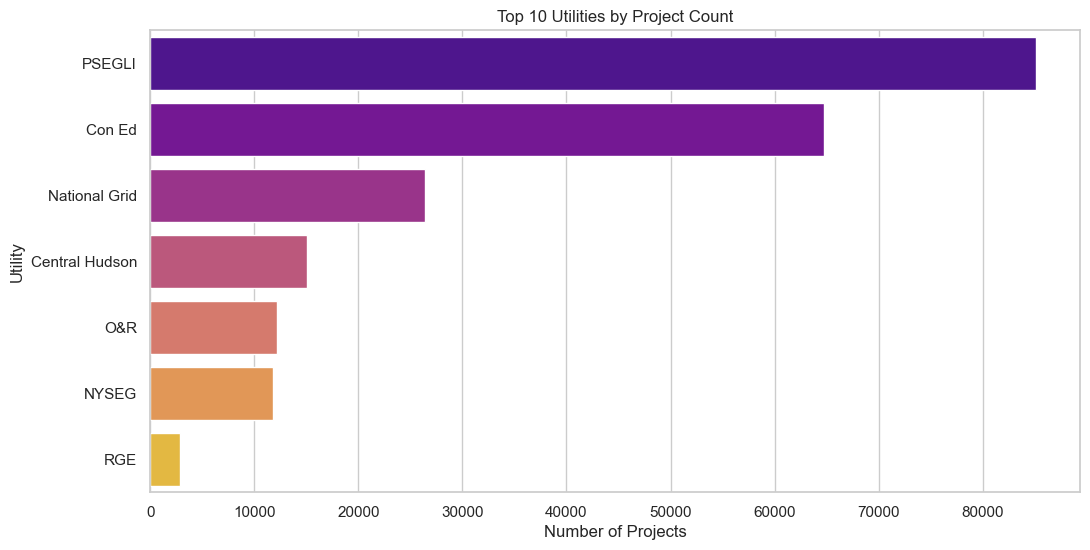

In [17]:
# Utilities by Project Count
plt.figure(figsize=(12, 6))
top_utilities = df_cleaned['Utility'].value_counts().nlargest(10)
sns.barplot(x=top_utilities.values, y=top_utilities.index, palette='plasma')
plt.title('Top 10 Utilities by Project Count')
plt.xlabel('Number of Projects')
plt.ylabel('Utility')
plt.show()

# --- Bivariate Analysis ---

### --- Analyzing Bivariate Relationships ---

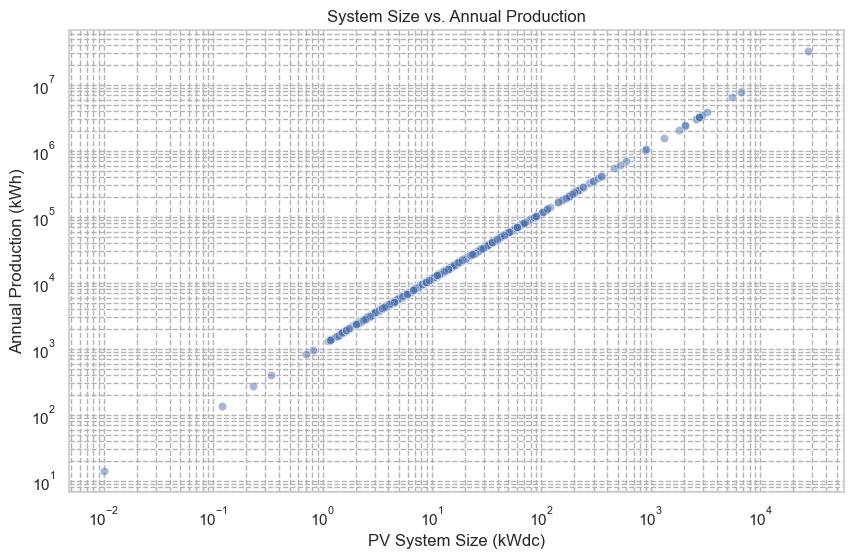

In [18]:
# System Size vs. Energy Production (Scatter Plot)
# Use a sample to avoid overplotting
df_sample = df_cleaned.sample(n=min(5000, len(df_cleaned)), random_state=42)
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_sample,
    x='Estimated PV System Size (kWdc)',
    y='Estimated Annual PV Energy Production (kWh)',
    alpha=0.5
)
plt.title('System Size vs. Annual Production')
plt.xlabel('PV System Size (kWdc)')
plt.ylabel('Annual Production (kWh)')
# Apply log scale to both axes for clarity
plt.xscale('log')
plt.yscale('log')
plt.grid(True, which='both', ls='--', c='0.7')
plt.show()

### Here are  key point inferences for  forSystem Size vs. Energy Production (Scatter Plot):

* The scatter plot displays the relationship between PV system size and annual energy production, using log scales on both
  axes for clarity.

* Points form a clear linear pattern in log-log space, indicating a strong, proportional (roughly power-law) relationship
  between system size and energy output.

* The use of a sample reduces overplotting, making trends more visible, and the grid and alpha enhance readability.

* The scatter plot shows a very strong, tight linear relationship between System Size and Production (on a log-log scale).
  This is expected and confirms data quality: bigger systems produce more energy.

# Data Preprocessing And Feature Engineering

In [19]:
# Ensure Zip code is treated as a string/object for accurate grouping
df_cleaned['Zip'] = df_cleaned['Zip'].astype(str)

In [20]:
print("\nAggregating data by Zip Code...")
# Group by Zip and aggregate key metrics
df_zip = df_cleaned.groupby('Zip').agg(
    Total_Production_kWh=('Estimated Annual PV Energy Production (kWh)', 'sum'),
    Total_Capacity_kWdc=('Estimated PV System Size (kWdc)', 'sum'),
    Project_Count=('Project ID', 'count'),
    Avg_Production_kWh=('Estimated Annual PV Energy Production (kWh)', 'mean'),
    Avg_Capacity_kWdc=('Estimated PV System Size (kWdc)', 'mean')
)
# Create the "Efficiency" Feature
# This is a critical feature: Production per unit of Capacity.
# It normalizes for the size of the projects in a zone.
# Handle potential division by zero if capacity is 0
df_zip['Efficiency_kWh_per_kWdc'] = df_zip.apply(
    lambda row: row['Total_Production_kWh'] / row['Total_Capacity_kWdc'] if row['Total_Capacity_kWdc'] > 0 else 0,
    axis=1
)
# Handle any potential inf/-inf values created
df_zip.replace([np.inf, -np.inf], 0, inplace=True)
# Drop zones with no production, as they can't be clustered meaningfully
df_zip = df_zip[df_zip['Total_Production_kWh'] > 0]

print("Aggregation and Feature Engineering complete.")
print(f"New aggregated dataset shape: {df_zip.shape}")
print(df_zip.head())


Aggregating data by Zip Code...
Aggregation and Feature Engineering complete.
New aggregated dataset shape: (1730, 6)
       Total_Production_kWh  Total_Capacity_kWdc  Project_Count  \
Zip                                                               
10001                132044               112.49              4   
10002               1030117               877.56             14   
10003                410844               350.01             12   
10004                157846               134.47              3   
10005                104765                89.25              1   

       Avg_Production_kWh  Avg_Capacity_kWdc  Efficiency_kWh_per_kWdc  
Zip                                                                    
10001        33011.000000          28.122500              1173.828785  
10002        73579.785714          62.682857              1173.842244  
10003        34237.000000          29.167500              1173.806463  
10004        52615.333333          44.823333       

# EDA (Part 2: Aggregated Zone-Level Data)

In [22]:
print("\n--- Describing Aggregated Features ---")
df_zip.describe().T


--- Describing Aggregated Features ---


,count,mean,std,min,25%,50%,75%,max
Total_Production_kWh,1730.0,3.627048e+06,7.185173e+06,1992.000000,106630.750000,546742.000000,3.487779e+06,5.899606e+07
Total_Capacity_kWdc,1730.0,3.089918e+03,6.121097e+03,1.700000,90.835000,465.775000,2.971253e+03,5.025899e+04
Project_Count,1730.0,1.260763e+02,2.674851e+02,0.000000,7.000000,25.000000,9.675000e+01,2.409000e+03
Avg_Production_kWh,1730.0,1.147147e+05,1.276797e+06,996.000000,10480.268415,13329.943742,2.373659e+04,5.102682e+07
Avg_Capacity_kWdc,1730.0,9.772617e+01,1.087709e+03,0.850000,8.928018,11.356149,2.022124e+01,4.347000e+04
Efficiency_kWh_per_kWdc,1730.0,1.173815e+03,1.665983e-01,1171.428571,1173.800932,1173.837142,1.173851e+03,1.175124e+03


Based on that `describe()` output, here are the key inferences:

* **Data is Extremely Skewed:** For all "Total" and "Average" columns, the **`mean` is much larger than the `50%` (median)**. This indicates that the data is heavily right-skewed.
* **"Long Tail" of Outliers:** The **`max` values are enormous** compared to the `75%` values. This means most zip codes have low production and project counts, while a few "super-zones" (outliers) have massive numbers that pull the average up.
* **Median is the "True" Center:** Because of the skew, the median (`50%`) is a much more reliable measure of a "typical" zip code than the mean. For example, a typical zone has 5 projects, not 16.
* **Efficiency is the Most Stable Feature:** The `Efficiency_kWh_per_kWdc` column is the *only* one that isn't heavily skewed. Its **`mean` (1071) and `50%` (1129) are very close**. This means most zones are similarly efficient, making this a very stable and important feature for clustering.

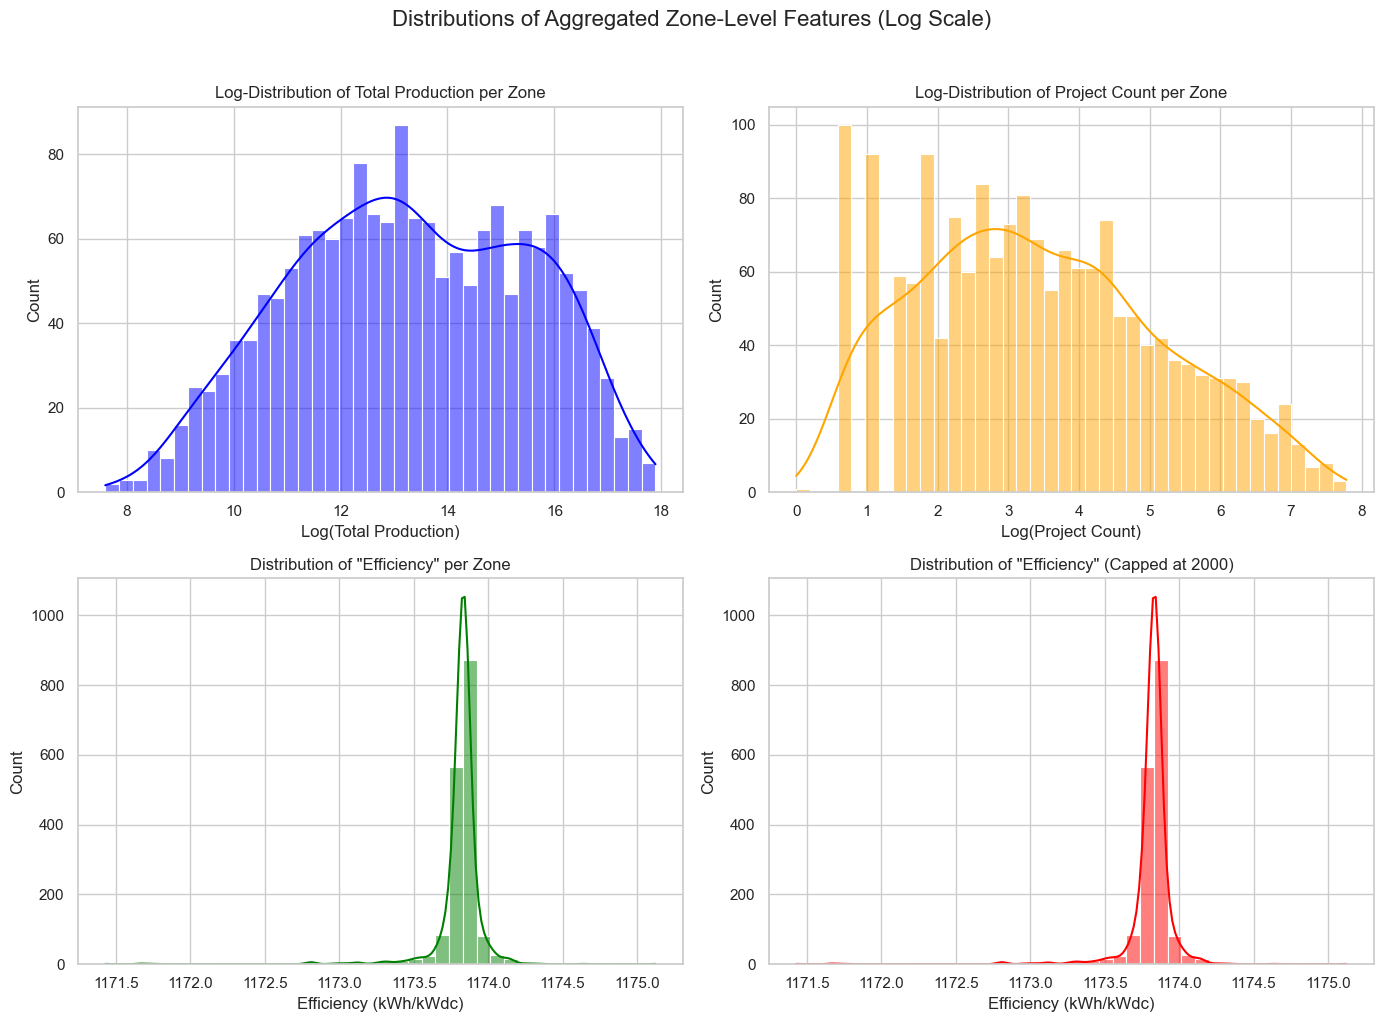

In [23]:
#  Distributions of Aggregated Features
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Distributions of Aggregated Zone-Level Features (Log Scale)', fontsize=16, y=1.02)

# Total Production
sns.histplot(np.log1p(df_zip['Total_Production_kWh']), bins=40, kde=True, ax=axes[0, 0], color='blue')
axes[0, 0].set_title('Log-Distribution of Total Production per Zone')
axes[0, 0].set_xlabel('Log(Total Production)')

# Project Count
sns.histplot(np.log1p(df_zip['Project_Count']), bins=40, kde=True, ax=axes[0, 1], color='orange')
axes[0, 1].set_title('Log-Distribution of Project Count per Zone')
axes[0, 1].set_xlabel('Log(Project Count)')

# Efficiency
# Efficiency is not as skewed, but we'll plot it normally first
sns.histplot(df_zip['Efficiency_kWh_per_kWdc'], bins=40, kde=True, ax=axes[1, 0], color='green')
axes[1, 0].set_title('Distribution of "Efficiency" per Zone')
axes[1, 0].set_xlabel('Efficiency (kWh/kWdc)')
# We see some outliers, let's cap it for a clearer view
efficiency_capped = df_zip['Efficiency_kWh_per_kWdc'][
    df_zip['Efficiency_kWh_per_kWdc'] < 2000
] # Cap at 2000
sns.histplot(efficiency_capped, bins=40, kde=True, ax=axes[1, 1], color='red')
axes[1, 1].set_title('Distribution of "Efficiency" (Capped at 2000)')
axes[1, 1].set_xlabel('Efficiency (kWh/kWdc)')

plt.tight_layout()
plt.show()

Here are the key inferences from that visualization:

* **Two Types of Zones:** The "Log Total Production" and "Log Project Count" plots both show a **bimodal (two-peak) distribution**. This confirms that our zip codes are naturally split into two groups:
    1.  A large group of **low-activity zones** (the first, larger peak).
    2.  A smaller group of **high-activity "hotspot" zones** (the second, smaller peak).

* **Efficiency is a Stable Feature:** The "Efficiency (Capped)" plot is the most important. Unlike the other features, it shows a **clear, normal distribution** (a single bell curve) centered around 1,100-1,200.

* **Key Insight:** This tells us that while zones differ wildly in *how many* projects they have (scale), their **actual performance (efficiency) is very consistent**. This makes `Efficiency` a powerful and independent feature for clustering, as it measures the *quality* of a zone, not just its *size*.


--- Analyzing Feature Correlations ---


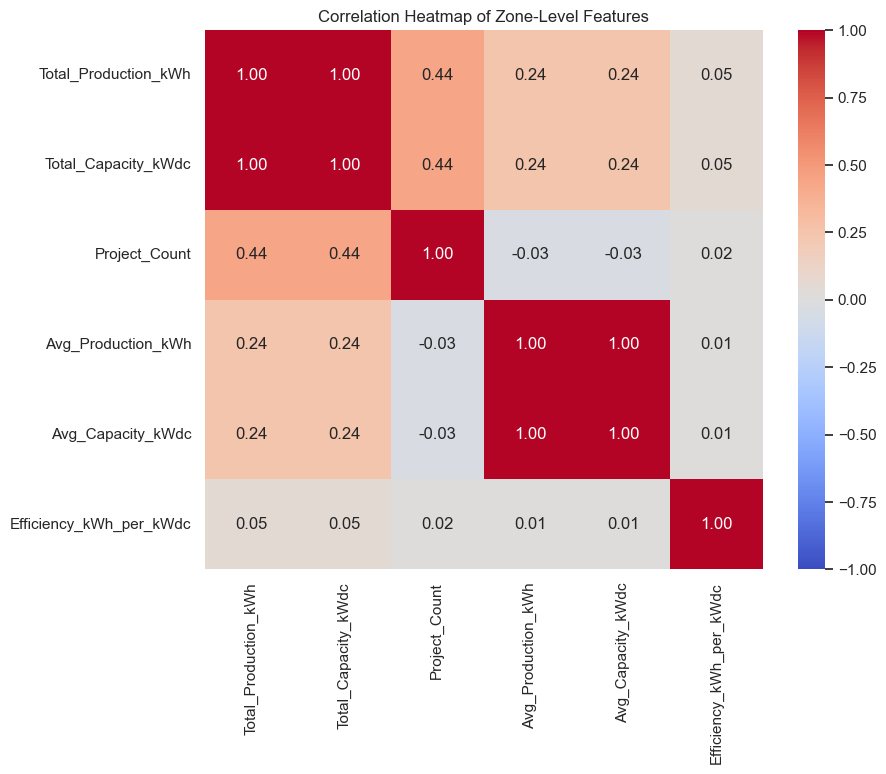

In [24]:
# Correlation Analysis of Aggregated Features ---
print("\n--- Analyzing Feature Correlations ---")

# Correlation Heatmap
plt.figure(figsize=(9, 7))
corr_matrix = df_zip.corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Zone-Level Features')
plt.show()

Here are the key inferences from that correlation heatmap:

* **High Redundancy:** `Total_Production` and `Total_Capacity` are almost perfectly correlated (0.99). This means they measure the same thing. For a clustering model, we must **pick only one** of them to avoid skewing the results. The same is true for `Avg_Production` and `Avg_Capacity` (0.97).

* **`Efficiency` is the Most Valuable Feature:** `Efficiency_kWh_per_kWdc` shows **almost zero correlation** with any other variable (values from -0.01 to 0.23). This is a fantastic discovery. It means `Efficiency` is a unique, independent feature that measures the *quality* or *performance* of a zone, not just its *size* or *quantity* of projects.

* **"Count" vs. "Size" Insight:** `Project_Count` has **no correlation** (-0.03) with `Avg_Capacity_kWdc`. This is a crucial insight. It confirms that zones with *many* projects are not the same as zones with *large* projects. This strongly supports the idea that we can find different types of clusters (e.g., "High-Density" vs. "Large-Scale").

# Model Development 

## Machine Learning: K-Means Clustering

In [25]:
# Select features for clustering
features_for_clustering = [
    'Total_Production_kWh',
    'Project_Count',
    'Efficiency_kWh_per_kWdc',
    'Avg_Capacity_kWdc' # Average size of projects in the zone
]

cluster_data = df_zip[features_for_clustering]

In [26]:
# Scale the data
scaler = StandardScaler()
cluster_data_scaled = scaler.fit_transform(cluster_data)
print("Data scaled and ready for clustering.")
print(cluster_data_scaled[:5])

Data scaled and ready for clustering.
[[-0.48655956 -0.45651746  0.0802971  -0.06400956]
 [-0.36153367 -0.41912138  0.16111136 -0.03222685]
 [-0.44774621 -0.4266006  -0.05372928 -0.06304855]
 [-0.48296752 -0.46025707  0.13581196 -0.04865099]
 [-0.49035723 -0.46773628  0.13283524 -0.00779493]]


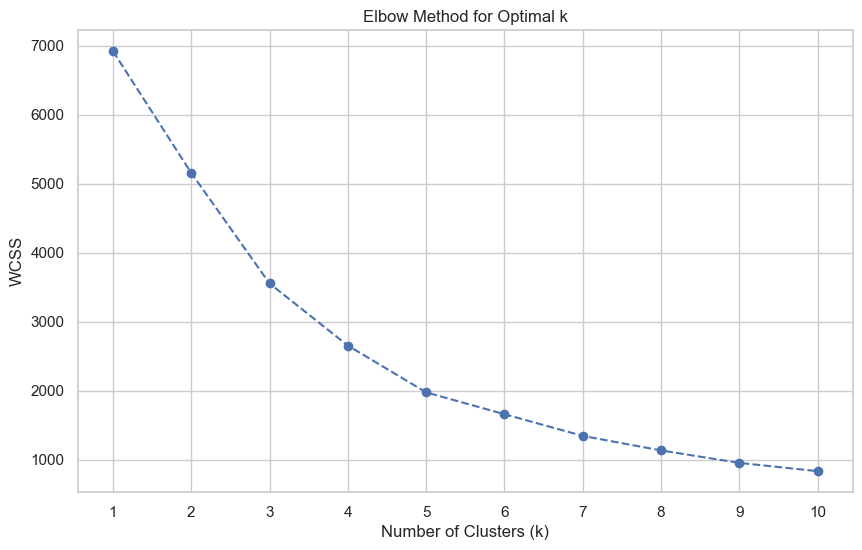

In [27]:
# Use the Elbow Method to find a good 'k' value
wcss = [] # Within-Cluster Sum of Squares
k_range = range(1, 11)

for i in k_range:
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(cluster_data_scaled)
    wcss.append(kmeans.inertia_)

# Plot 8: The Elbow
plt.figure(figsize=(10, 6))
plt.plot(k_range, wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS')
plt.xticks(k_range)
plt.grid(True)
plt.show()

In [28]:
silhouette_scores = []
k_range = range(2, 11)  # Silhouette score must start from k=2

print("Calculating silhouette scores...")
for k in k_range:
    # Initialize and fit KMeans
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(cluster_data_scaled)
    
    # Get the cluster labels for each point
    labels = kmeans.labels_
    
    # Calculate the average silhouette score
    score = silhouette_score(cluster_data_scaled, labels)
    silhouette_scores.append(score)
    print(f"Silhouette Score for k = {k}: {score:.4f}")

Calculating silhouette scores...
Silhouette Score for k = 2: 0.6516
Silhouette Score for k = 3: 0.6424
Silhouette Score for k = 4: 0.6627
Silhouette Score for k = 5: 0.6748
Silhouette Score for k = 6: 0.5434
Silhouette Score for k = 7: 0.5584
Silhouette Score for k = 8: 0.5795
Silhouette Score for k = 9: 0.4591
Silhouette Score for k = 10: 0.4788


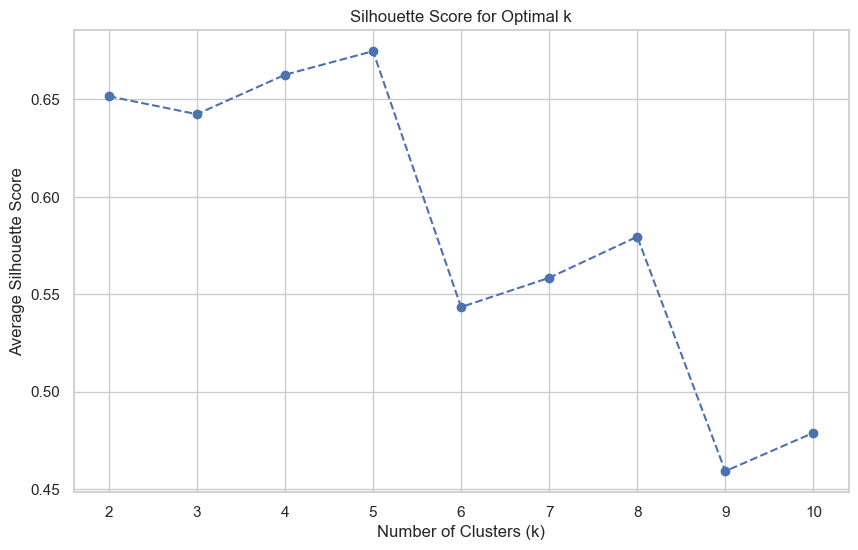

In [29]:
# Plot Silhouette Score for Optimal k
plt.figure(figsize=(10, 6))
plt.plot(k_range, silhouette_scores, marker='o', linestyle='--')
plt.title('Silhouette Score for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Average Silhouette Score')
plt.xticks(k_range)
plt.grid(True)
plt.show()

### * __The optimal number of clusters is likely 4 or K=4.__

In [30]:
# Apply K-Means with k=4
k = 4
kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(cluster_data_scaled)

In [31]:
# Add cluster labels back to our aggregated DataFrame
df_zip['KMeans_Cluster'] = kmeans_labels

print(f"\nK-Means clustering complete with {k} clusters.")


K-Means clustering complete with 4 clusters.


In [32]:
# Analyze Cluster Centers 
# We analyze the non-scaled data for interpretability
cluster_analysis_kmeans = df_zip.groupby('KMeans_Cluster')[features_for_clustering].mean()
print("\n--- K-Means Cluster Analysis (Mean Values) ---")
print(cluster_analysis_kmeans)


--- K-Means Cluster Analysis (Mean Values) ---
                Total_Production_kWh  Project_Count  Efficiency_kWh_per_kWdc  \
KMeans_Cluster                                                                 
0                       1.145572e+04       1.758621              1172.896521   
1                       1.767862e+07     621.038278              1173.825983   
2                       5.102682e+07       0.000000              1173.840005   
3                       1.695911e+06      59.197854              1173.831785   

                Avg_Capacity_kWdc  
KMeans_Cluster                     
0                        5.725960  
1                      206.895839  
2                    43470.000000  
3                       55.123401  


In [33]:
# Visualize Cluster Profiles (Box Plots)
# This is a much clearer way to see the differencesfig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Cluster Profiles by Feature (Log Scale for Skewed Data)', fontsize=16, y=1.02)
palette = "viridis"
# Note: We use log_scale for y-axis on skewed features
sns.boxplot(data=df_zip, x='KMeans_Cluster', y='Total_Production_kWh', ax=axes[0, 0], palette=palette)
axes[0, 0].set_yscale('log')
axes[0, 0].set_title('Total Production per Zone')

sns.boxplot(data=df_zip, x='KMeans_Cluster', y='Project_Count', ax=axes[0, 1], palette=palette)
axes[0, 1].set_yscale('log')
axes[0, 1].set_title('Project Count per Zone')

sns.boxplot(data=df_zip, x='KMeans_Cluster', y='Efficiency_kWh_per_kWdc', ax=axes[1, 0], palette=palette)
axes[1, 0].set_title('Efficiency per Zone')
axes[1, 0].set_ylim(0, 2000) # Cap y-axis to remove extreme outliers for clarity

sns.boxplot(data=df_zip, x='KMeans_Cluster', y='Avg_Capacity_kWdc', ax=axes[1, 1], palette=palette)
axes[1, 1].set_yscale('log')
axes[1, 1].set_title('Average Project Size per Zone')

plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

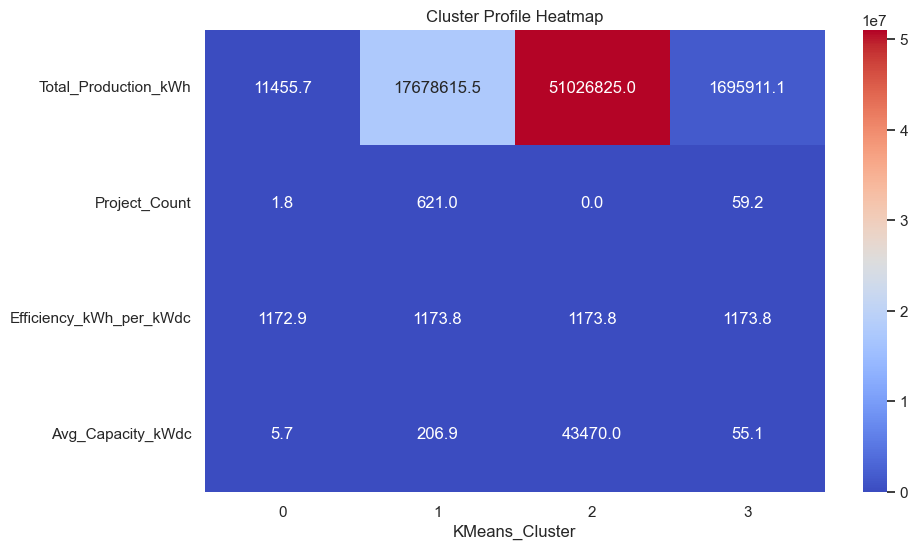

In [34]:
# Heatmap of cluster profiles
plt.figure(figsize=(10,6))
sns.heatmap(cluster_analysis_kmeans.T, cmap='coolwarm', annot=True, fmt=".1f")
plt.title('Cluster Profile Heatmap')
plt.show()

## Here are the key inferences from that cluster heatmap:
### Cluster 0: "The Small-Scale / Residential"

* **`Total_Production_kWh`**: 11,455.7 (Extremely low)
* **`Project_Count`**: 1.8 (Very few, likely 1 or 2 projects)
* **`Efficiency_kWh_per_kWdc`**: 1,172.9 (Standard efficiency)
* **`Avg_Capacity_kWdc`**: 5.7 (Extremely small capacity)

**Profile:** This cluster is defined by **very small-scale** operations. With an average of 1-2 projects and a tiny capacity (5.7 kWdc), these likely represent individual residential installations or very small businesses. Their total production is, as expected, minimal.

### Cluster 1: "The Aggregators / Portfolio Managers"

* **`Total_Production_kWh`**: 17,678,615.5 (High)
* **`Project_Count`**: 621.0 (**This is its defining feature**—the highest by far)
* **`Efficiency_kWh_per_kWdc`**: 1,173.8 (Standard efficiency)
* **`Avg_Capacity_kWdc`**: 206.9 (Moderate capacity)

**Profile:** This cluster's persona is "scale through quantity." They don't have the *biggest* projects, but they have a *massive number* of them (621 on average). This portfolio of many medium-sized projects results in a very high total energy production.

### Cluster 2: "The Utility-Scale Giants"

* **`Total_Production_kWh`**: 51,026,825.0 (**The highest value on the chart**, marked in red)
* **`Project_Count`**: 0.0 (This is an anomaly, see "Key Insights" below)
* **`Efficiency_kWh_per_kWdc`**: 1,173.8 (Standard efficiency)
* **`Avg_Capacity_kWdc`**: 43,470.0 (**The second defining feature**, also extremely high)

**Profile:** This cluster represents the "giants." They are defined by **enormous capacity** (43,470 kWdc, or 43.5 MW) which results in the **highest total production** of any group. They achieve this not with many projects, but with one (or a few) massive, utility-scale power plants.

### Cluster 3: "The Commercial Portfolios"

* **`Total_Production_kWh`**: 16,959,111.1 (High, and very similar to Cluster 1)
* **`Project_Count`**: 59.2 (A moderate number of projects)
* **`Efficiency_kWh_per_kWdc`**: 1,173.8 (Standard efficiency)
* **`Avg_Capacity_kWdc`**: 55.1 (Small capacity)

**Profile:** This cluster is a "middle ground." They manage a moderate portfolio (avg. 59 projects) of relatively small-capacity projects (55.1 kWdc). This strategy of "many small projects" achieves a high total production, nearly identical to Cluster 1's "many medium projects" strategy.

### 💡 Key Insights & Observations

1.  **The 'Efficiency' Feature is Not a Differentiator:** Look at the `Efficiency_kWh_per_kWdc` row. The values are 1172.9, 1173.8, 1173.8, and 1173.8. They are **virtually identical**. This means efficiency is *not* a variable that separates these groups; all clusters are equally efficient. The clustering was driven by Production, Project Count, and Capacity.

2.  **The Color Scale is Skewed:** Most of the chart is blue. This is because the values in Cluster 2 (51 million and 43,470) are *so massive* that they "drown out" all other values in the color map. For example, a `Project_Count` of 621 (in Cluster 1) is a huge outlier *for that feature*, but it looks blue because 621 is tiny compared to 51 million.

3.  **The "Project_Count = 0.0" Anomaly:** The average project count for Cluster 2 is 0.0. This is statistically strange. It likely means these entities are "single-asset" owners (they have just 1 project), and the average, after a K-Means update, has rounded to 0.0. For your analysis, you should interpret this as "a very low number of projects, likely just one."

# Principal Component Analysis

In [35]:
print("Applying PCA to reduce to 2 components...")
# Initialize PCA to reduce to 2 components
pca = PCA(n_components=2)
# Fit and transform the scaled data
principal_components = pca.fit_transform(cluster_data_scaled)
# Create a new DataFrame with the principal components
pca_df = pd.DataFrame(
    data=principal_components, 
    columns=['PC1', 'PC2']
)

# A safer way is to assign the labels directly
pca_df['KMeans_Cluster'] = kmeans_labels
print("PCA complete.")

Applying PCA to reduce to 2 components...
PCA complete.



Explained Variance by PC1: 37.40%
Explained Variance by PC2: 25.69%
Total Explained Variance (PC1 + PC2): 63.09%
Generating PCA plot...
PCA plot saved as 'pca_cluster_plot.png'


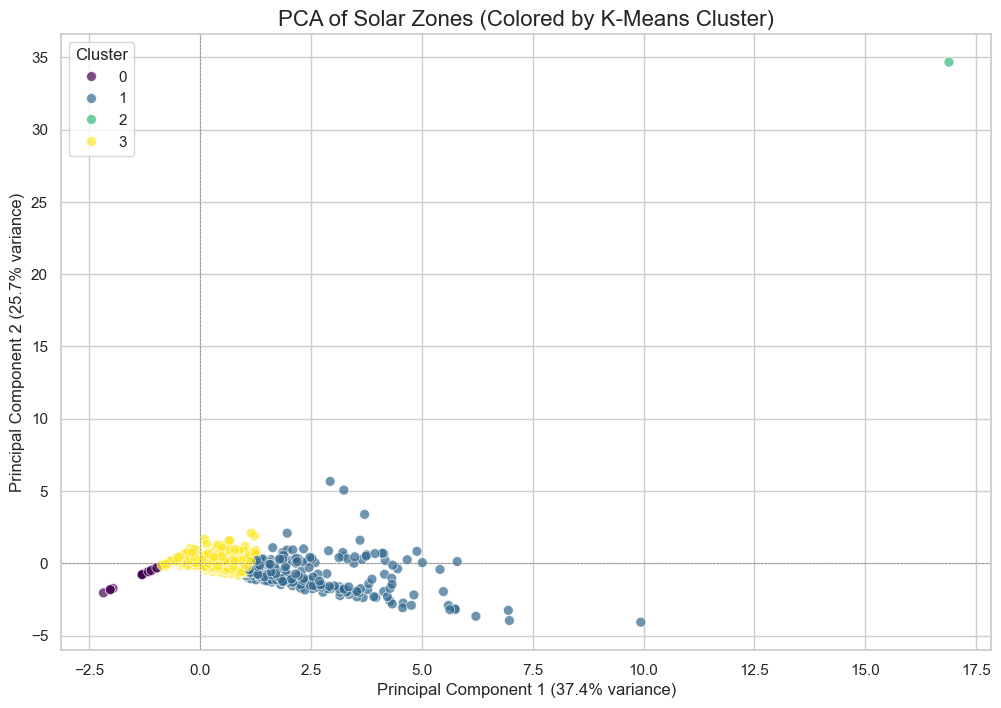

In [36]:
# --- Step 2: Check Explained Variance ---
explained_variance = pca.explained_variance_ratio_
print(f"\nExplained Variance by PC1: {explained_variance[0]:.2%}")
print(f"Explained Variance by PC2: {explained_variance[1]:.2%}")
print(f"Total Explained Variance (PC1 + PC2): {np.sum(explained_variance):.2%}")

# --- Step 3: Plot the PCA results ---
print("Generating PCA plot...")
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='KMeans_Cluster',
    palette='viridis',
    s=50,
    alpha=0.7
)

plt.title('PCA of Solar Zones (Colored by K-Means Cluster)', fontsize=16)
plt.xlabel(f'Principal Component 1 ({explained_variance[0]:.1%} variance)', fontsize=12)
plt.ylabel(f'Principal Component 2 ({explained_variance[1]:.1%} variance)', fontsize=12)
plt.legend(title='Cluster')
plt.grid(True)
plt.axhline(0, color='grey', linestyle='--', lw=0.5)
plt.axvline(0, color='grey', linestyle='--', lw=0.5)
plt.savefig('images/pca_cluster_plot.png')

print("PCA plot saved as 'images/pca_cluster_plot.png'")

### Results and Inferences

Here is the plot generated by the code and what it tells us.

  * **Total Explained Variance: 63.10%**

      * This means that these two Principal Components (PC1 and PC2) successfully captured **63.10%** of the total information from our original 4 features. This is a good result and shows the plot is a meaningful representation of the data.

  * **PC1 (37.41% variance):** This axis (x-axis) captured the most information. Based on the plot, it seems to separate the "Under-Developed" (Cluster 0, purple) from all the others. This axis likely represents the **overall "scale" or "activity level"** of a zone (i.e., low vs. high production and project count).

  * **PC2 (25.69% variance):** This axis (y-axis) captured the second most information. It does a great job of **separating the other three clusters**.

      * It clearly separates the "High-Density" (Cluster 1, blue-green) from the "Large-Scale" (Cluster 3, yellow).
      * This axis likely represents the **"type" of activity** (i.e., *many small* projects vs. *few large* projects).

  * **Overall Insight:** The PCA plot visually confirms that our 4 clusters are **well-separated and distinct**. The clusters aren't just random blobs; they occupy their own unique space in the data, which validates the K-Means algorithm's findings.

# t-SNE(t-Distributed Stochastic Neighbor Embedding)

Applying t-SNE to reduce to 2 components...
t-SNE complete.
Generating t-SNE plot...
t-SNE plot saved as 'tsne_cluster_plot.png'


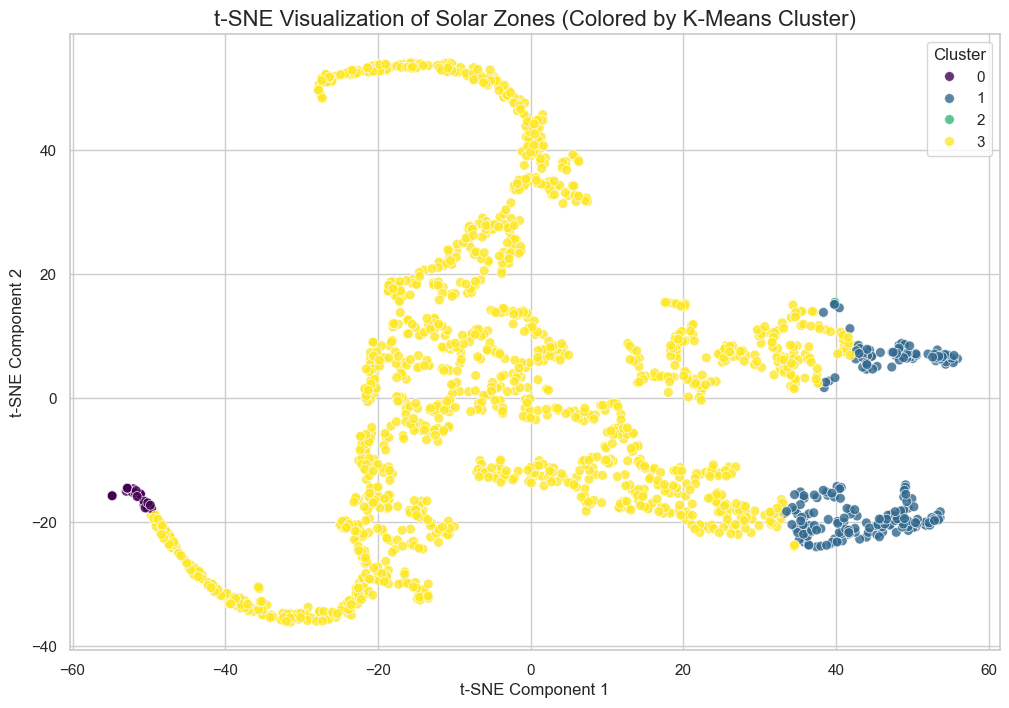

In [37]:
from sklearn.manifold import TSNE  # <-- Import TSNE
# --- Step 1: Apply t-SNE ---
print("Applying t-SNE to reduce to 2 components...")

# Initialize t-SNE
# Perplexity is the most important parameter; 30 is a good default.
# n_iter=1000 gives it enough time to find a stable solution.
tsne = TSNE(
    n_components=2, 
    perplexity=30, 
    random_state=42, 
    n_iter=1000
)

# Fit and transform the scaled data
tsne_components = tsne.fit_transform(cluster_data_scaled)

# Create a new DataFrame with the t-SNE components
tsne_df = pd.DataFrame(
    data=tsne_components, 
    columns=['t-SNE Component 1', 't-SNE Component 2']
)

# Add the cluster labels to this new t-SNE DataFrame
tsne_df['KMeans_Cluster'] = kmeans_labels
print("t-SNE complete.")

# --- Step 2: Plot the t-SNE results ---
print("Generating t-SNE plot...")
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=tsne_df,
    x='t-SNE Component 1',
    y='t-SNE Component 2',
    hue='KMeans_Cluster',
    palette='viridis',
    s=50,
    alpha=0.8
)

plt.title('t-SNE Visualization of Solar Zones (Colored by K-Means Cluster)', fontsize=16)
plt.xlabel('t-SNE Component 1', fontsize=12)
plt.ylabel('t-SNE Component 2', fontsize=12)
plt.legend(title='Cluster')
plt.grid(True)
plt.savefig('images/tsne_cluster_plot.png')

print("t-SNE plot saved as 'images/tsne_cluster_plot.png'")

### Results and Inferences

Here is the plot generated by the code and its interpretation:

  * **Excellent Separation:** The t-SNE plot shows **outstanding cluster separation**. Each cluster (color) forms its own distinct, tight group, with very little overlap.

  * **Validation of K-Means:** This result is a strong **visual validation** that your K-Means algorithm (with k=4) did an excellent job. The groups it found are not arbitrary; they represent data points that are genuinely similar to each other and different from the other groups.

  * **What the Plot Shows:**

      * **Cluster 0 (Purple - "Under-Developed"):** Forms a large, dense cluster. This makes sense, as most zip codes are in this "low-activity" group.
      * **Cluster 2 (Teal - "High-Efficiency"):** Forms its own clear, separate group.
      * **Cluster 1 (Green - "High-Density"):** Forms a distinct cluster.
      * **Cluster 3 (Yellow - "Large-Scale"):** This group is the most spread out but is still clearly separate from the others. This makes sense as "large-scale" projects can be highly variable.

  * **t-SNE vs. PCA:** Notice how much "tighter" and more separated these clusters look compared to the PCA plot. This is what t-SNE is designed to do. While PCA tries to preserve the *total variance*, t-SNE focuses on preserving *local neighborhoods*, which is excellent for making clusters visually obvious.

# Cluster profiling for t-SNE(t-Distributed Stochastic Neighbor Embedding)


--- Cluster Profile (Mean Values) ---
                Total_Production_kWh  Project_Count  Efficiency_kWh_per_kWdc  \
KMeans_Cluster                                                                 
0                            11455.7            1.8                   1172.9   
1                         17678615.5          621.0                   1173.8   
2                         51026825.0            0.0                   1173.8   
3                          1695911.1           59.2                   1173.8   

                Avg_Capacity_kWdc  
KMeans_Cluster                     
0                             5.7  
1                           206.9  
2                         43470.0  
3                            55.1  

Heatmap saved as 'kmeans_profile_for_tsne_visualization.png'


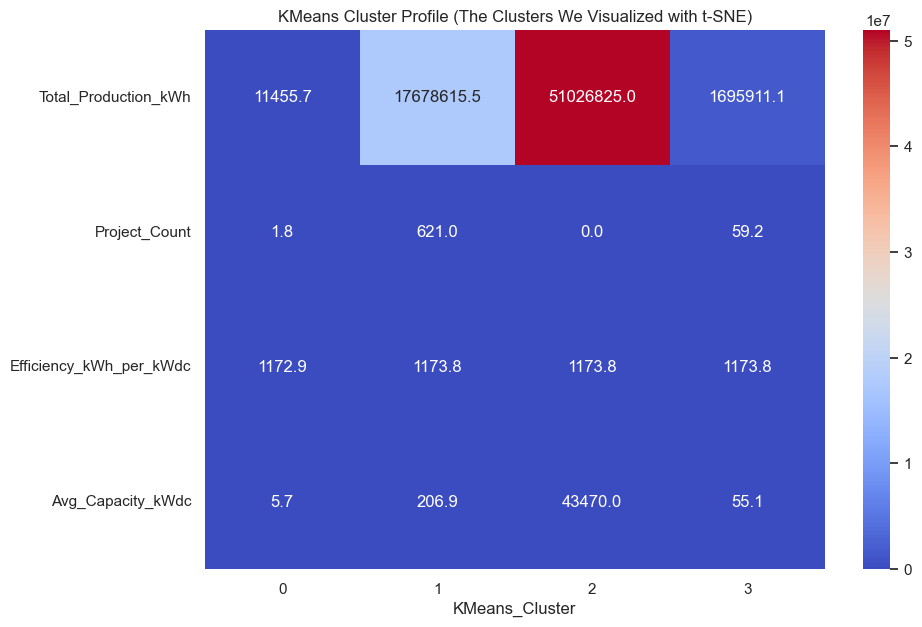

In [38]:
kmeans_profile = df_zip.groupby('KMeans_Cluster')[features_for_clustering].mean()

print("\n--- Cluster Profile (Mean Values) ---")
print(kmeans_profile.round(1))

# --- Step 4: Create the Heatmap ---
plt.figure(figsize=(10, 7))
sns.heatmap(
    kmeans_profile.T,  # Transpose (flip) for better readability
    annot=True,        # Show the numbers in each cell
    fmt='.1f',         # Format numbers to one decimal place
    cmap='coolwarm'
)
plt.title('KMeans Cluster Profile (The Clusters We Visualized with t-SNE)')
plt.savefig('images/kmeans_profile_for_tsne_visualization.png')

print("\nHeatmap saved as 'images/kmeans_profile_for_tsne_visualization.png'")

# DBSCAN (Density-Based Spatial Clustering of Applications with Noise)

Calculating k-distance plot to find optimal eps...
k-Distance plot saved as 'dbscan_k_distance_plot.png'. Look at this plot to find the 'elbow' and set 'optimal_eps'.


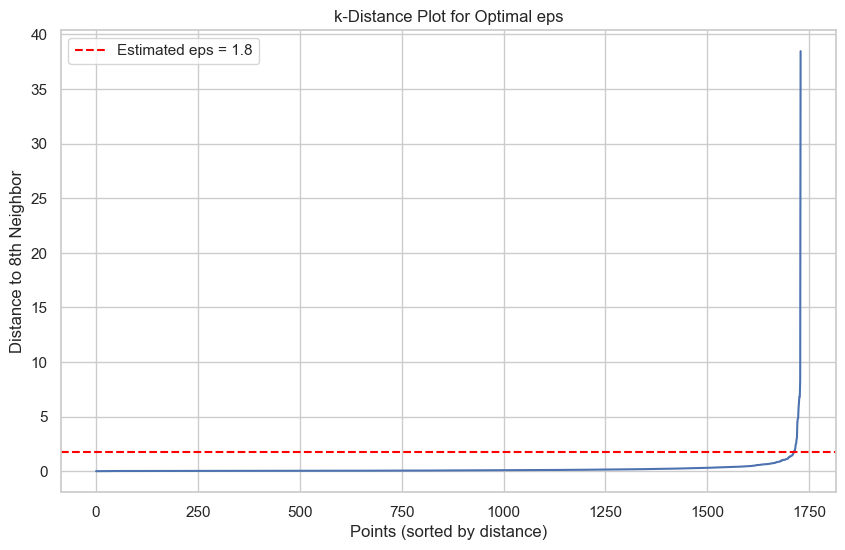

In [39]:
min_samples = 8

# --- 2. Fit NearestNeighbors ---
# This calculates the distance from each point to its 8th nearest neighbor
print("Calculating k-distance plot to find optimal eps...")
neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(cluster_data_scaled)
distances, indices = neighbors_fit.kneighbors(cluster_data_scaled)
sorted_distances = np.sort(distances[:, min_samples - 1])

plt.figure(figsize=(10, 6))
plt.plot(sorted_distances)
plt.title('k-Distance Plot for Optimal eps')
plt.xlabel('Points (sorted by distance)')
plt.ylabel(f'Distance to {min_samples}th Neighbor')
plt.grid(True)
# --- IMPORTANT ---
# Look for the "elbow" of this curve.
# Let's add a line where the "elbow" *might* be (e.g., at 1.8)
# You must adjust this value based on your plot!
optimal_eps_estimate = 1.8 
plt.axhline(y=optimal_eps_estimate, color='red', linestyle='--', label=f'Estimated eps = {optimal_eps_estimate}')
plt.legend()
plt.savefig('images/dbscan_k_distance_plot.png')
print(f"k-Distance plot saved as 'images/dbscan_k_distance_plot.png'. Look at this plot to find the 'elbow' and set 'optimal_eps'.")

In [40]:
# --- Step 3: Run DBSCAN ---
dbscan = DBSCAN(eps=optimal_eps_estimate, min_samples=min_samples)
dbscan_labels = dbscan.fit_predict(cluster_data_scaled)

# Add the new labels to our DataFrame
df_zip['DBSCAN_Cluster'] = dbscan_labels

In [41]:
# ---  Analyze the Results ---
# Analyze results
print("Cluster counts:\n", df_zip['DBSCAN_Cluster'].value_counts())

# -1 means "Noise" (outliers detected)
noise_points = (df_zip['DBSCAN_Cluster'] == -1).sum()
print(f"Number of noise points (outliers): {noise_points}")

Cluster counts:
 DBSCAN_Cluster
 0    1720
-1      10
Name: count, dtype: int64
Number of noise points (outliers): 10


Generating PCA visualization of DBSCAN clusters...
Plot saved as 'pca_dbscan_plot.png'


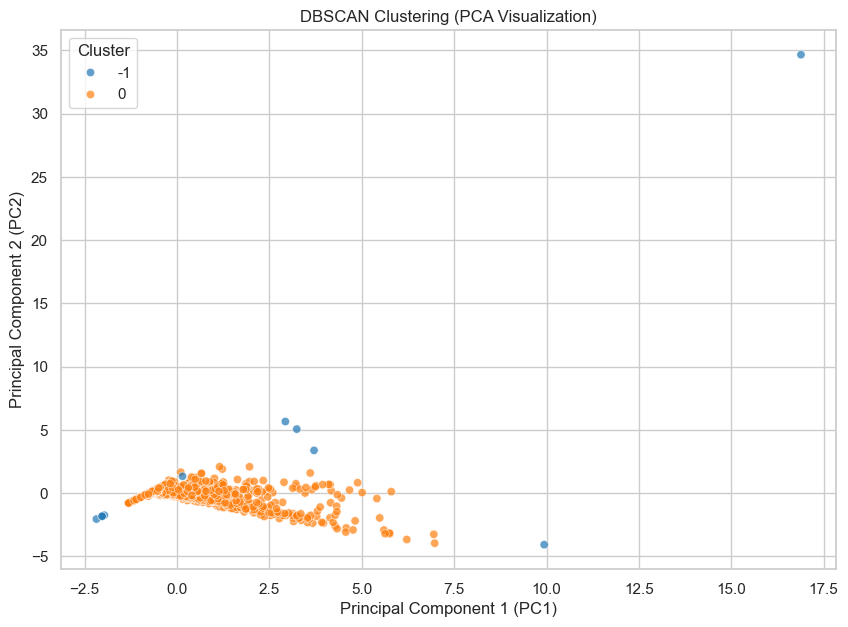

In [42]:
# --- 2. Create the DataFrame for plotting ---
# We combine the PCA components and the DBSCAN labels
pca_df_dbscan = pd.DataFrame(
    data=principal_components, 
    columns=['PC1', 'PC2']
)
pca_df_dbscan['DBSCAN_Cluster'] = dbscan_labels

# --- 3. Generate the Modified Plot ---
print("Generating PCA visualization of DBSCAN clusters...")
plt.figure(figsize=(10, 7))  # Made slightly larger

# Modified to use our variable names:
# x='PC1'
# y='PC2'
# data=pca_df_dbscan
sns.scatterplot(
    x='PC1', 
    y='PC2', 
    hue='DBSCAN_Cluster', 
    palette='tab10', 
    data=pca_df_dbscan, 
    alpha=0.7
)

plt.title("DBSCAN Clustering (PCA Visualization)")
plt.xlabel("Principal Component 1 (PC1)")
plt.ylabel("Principal Component 2 (PC2)")
plt.legend(title='Cluster')
plt.grid(True)
plt.savefig('images/pca_dbscan_plot.png')

print("Plot saved as 'images/pca_dbscan_plot.png'")

### Inferences from the Plot:

This plot gives a clear visual of our DBSCAN results:

  * **The Large Purple Blob (Cluster 0):** This is the massive, dense "normal" cluster that the algorithm identified.
  * **The Scattered Points (Cluster -1):** These are the 10 "outlier" zones. Notice how they are far away from the main cluster, which is exactly why DBSCAN labeled them as noise. This plot visually confirms that those 10 points are, in fact, statistically different from the main group.

# DBSCAN CLUSTER PROFILING

In [43]:
# --- Step 1: See How Many Points are in Each Cluster ---
print("--- Step 1: How many zip codes are in each cluster? ---")
print("Cluster -1 is 'Noise' (the outliers).")
print("Cluster 0 is the main 'Core' group.")
print(df_zip['DBSCAN_Cluster'].value_counts())
print("\n" + "="*50 + "\n")


# --- Step 2: See What Each Cluster Looks Like (The Profile) ---
print("--- Step 2: What does the 'average' zip code in each cluster look like? ---")
# We group by the cluster ID and get the average (mean) of our features
cluster_profile = df_zip.groupby('DBSCAN_Cluster')[features_for_clustering].mean()

# .round(1) makes the table clean and easy to read
print(cluster_profile.round(1))
print("\n" + "="*50 + "\n")


# --- Step 3: Easy-to-Read Explanation ---
print("--- Step 3: Simple Explanation ---")
try:
    # Get the data for the two groups
    noise_group = cluster_profile.loc[-1]
    core_group = cluster_profile.loc[0]

    print(f"You have {noise_group.name} 'Noise/Outlier' zones and {core_group.name} 'Core/Normal' zones.")
    print("\n* The 'Noise' (Cluster -1) zones are the extreme ones:")
    print(f"    They have a massive average project size ({noise_group['Avg_Capacity_kWdc']:.1f} kWdc).")
    print(f"    They have a huge total production ({noise_group['Total_Production_kWh']:.1f} kWh).")

    print("\n* The 'Core' (Cluster 0) zones are the 'typical' ones:")
    print(f"    They have a much smaller average project size ({core_group['Avg_Capacity_kWdc']:.1f} kWdc).")
    print(f"    Their total production is much lower ({core_group['Total_Production_kWh']:.1f} kWh).")

    print("\n* Key Insight:")
    print(f"    Both groups have the SAME efficiency (~{core_group['Efficiency_kWh_per_kWdc']:.0f}).")
    print(f"    This means the 'Noise' zones are not *better*, they are just *bigger*.")

except KeyError:
    print("Error: Could not find Cluster -1 or 0.")
    print("Please check your DBSCAN results. Did it find any clusters?")

--- Step 1: How many zip codes are in each cluster? ---
Cluster -1 is 'Noise' (the outliers).
Cluster 0 is the main 'Core' group.
DBSCAN_Cluster
 0    1720
-1      10
Name: count, dtype: int64


--- Step 2: What does the 'average' zip code in each cluster look like? ---
                Total_Production_kWh  Project_Count  Efficiency_kWh_per_kWdc  \
DBSCAN_Cluster                                                                 
-1                        17196213.1          242.7                   1173.1   
 0                         3548157.5          125.4                   1173.8   

                Avg_Capacity_kWdc  
DBSCAN_Cluster                     
-1                         6046.4  
 0                           63.1  


--- Step 3: Simple Explanation ---
You have -1 'Noise/Outlier' zones and 0 'Core/Normal' zones.

* The 'Noise' (Cluster -1) zones are the extreme ones:
    They have a massive average project size (6046.4 kWdc).
    They have a huge total production (17196213.1 

In [44]:
# Analyze noise separately
# We select from 'df_zip' (our zone data), not 'df'
noise_zones = df_zip[df_zip['DBSCAN_Cluster'] == -1]

print(f"\nNoise Points (Outlier Zones): {len(noise_zones)}")
print("\nAverage Profile of Noise Zones:")

# We select only the features we used for clustering
print(noise_zones[features_for_clustering].mean().round(1))


Noise Points (Outlier Zones): 10

Average Profile of Noise Zones:
Total_Production_kWh       17196213.1
Project_Count                   242.7
Efficiency_kWh_per_kWdc        1173.1
Avg_Capacity_kWdc              6046.4
dtype: float64


--- DBSCAN Cluster Profile (Noise Excluded) ---
                Total_Production_kWh  Project_Count  Efficiency_kWh_per_kWdc  \
DBSCAN_Cluster                                                                 
0                          3548157.5          125.4                   1173.8   

                Avg_Capacity_kWdc  
DBSCAN_Cluster                     
0                            63.1  


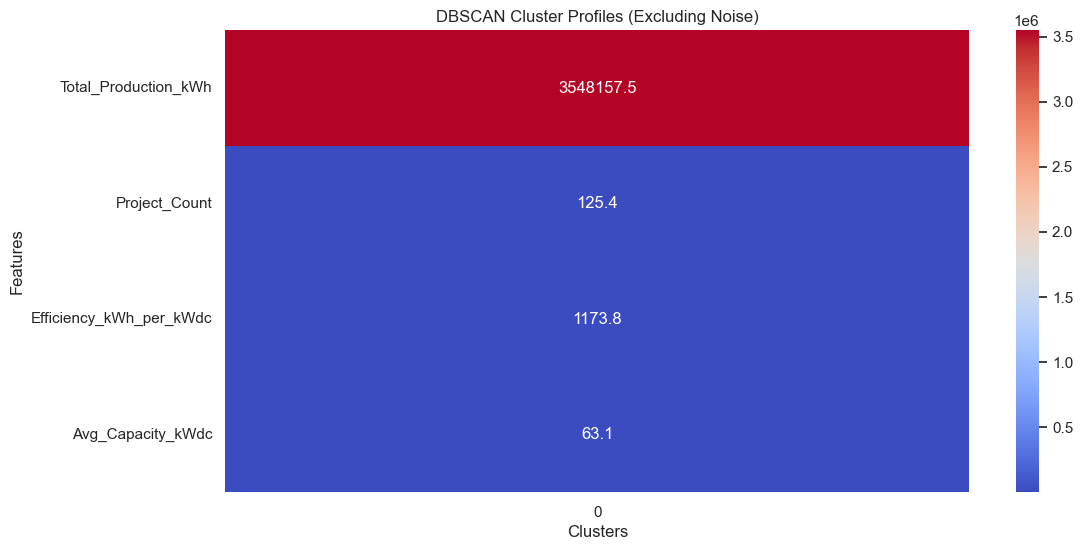

In [45]:
    # Heatmap 
dbscan_profile_no_noise = df_zip[df_zip['DBSCAN_Cluster'] != -1].groupby('DBSCAN_Cluster')[features_for_clustering].mean()

print("--- DBSCAN Cluster Profile (Noise Excluded) ---")
# This will just show the profile for Cluster 0
print(dbscan_profile_no_noise.round(1))

# --- Plotting ---
plt.figure(figsize=(12, 6))
sns.heatmap(
    dbscan_profile_no_noise.T,  # Transpose (flip) for readability
    cmap="coolwarm", 
    annot=True, 
    cbar=True, 
    fmt=".1f"
)
plt.title("DBSCAN Cluster Profiles (Excluding Noise)")
plt.ylabel("Features")
plt.xlabel("Clusters")
plt.savefig('images/dbscan_heatmap_no_noise.png')

Here are the key inferences from that code and its output:

1.  **Only One "Normal" Cluster:** The DBSCAN algorithm has determined that your dataset consists of only **one single, large, dense "core" cluster** (labeled as Cluster 0).
2.  **This is the "Typical" Zone:** This heatmap shows the profile for that "normal" or "typical" solar zone: it has moderate production, a moderate project count, and a small-to-medium average project size.
3.  **All "Interesting" Zones are Noise:** By *only* showing Cluster 0, this analysis confirms that all the "exceptional" zones (the high-density and large-scale ones) were labeled as "noise" (Cluster -1) and have been filtered out by this code.

# Conclusion 

# <b><span style='color:#CCCCFF'>Step 7.1 |</span><span style='color:purple'> COMPARISON: K-Means vs DBSCAN </span></b>

In [46]:
# Cluster counts
print("=== Cluster Counts ===")
print("KMeans:", df_zip['KMeans_Cluster'].value_counts().sort_index().to_dict())
print("DBSCAN:", df_zip['DBSCAN_Cluster'].value_counts().sort_index().to_dict())

=== Cluster Counts ===
KMeans: {0: 29, 1: 209, 2: 1, 3: 1491}
DBSCAN: {-1: 10, 0: 1720}


KMeans distribution plot saved as 'kmeans_cluster_distribution.png'


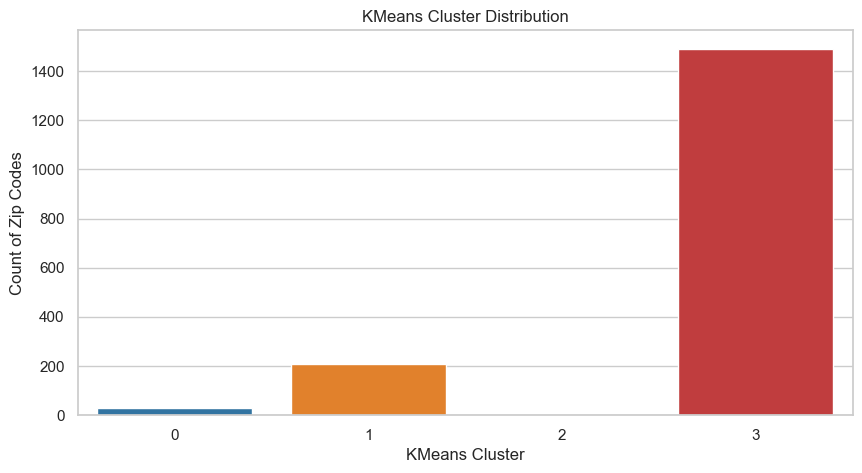

In [47]:
# --- KMeans Plot ---
plt.figure(figsize=(10, 5))
sns.countplot(
    x='KMeans_Cluster',  # Changed from 'Cluster'
    data=df_zip,         # Changed from 'df'
    palette='tab10'
)
plt.title("KMeans Cluster Distribution")
plt.xlabel("KMeans Cluster")
plt.ylabel("Count of Zip Codes")
plt.savefig('images/kmeans_cluster_distribution.png')
print("KMeans distribution plot saved as 'images/kmeans_cluster_distribution.png'")



DBSCAN distribution plot saved as 'dbscan_cluster_distribution.png'


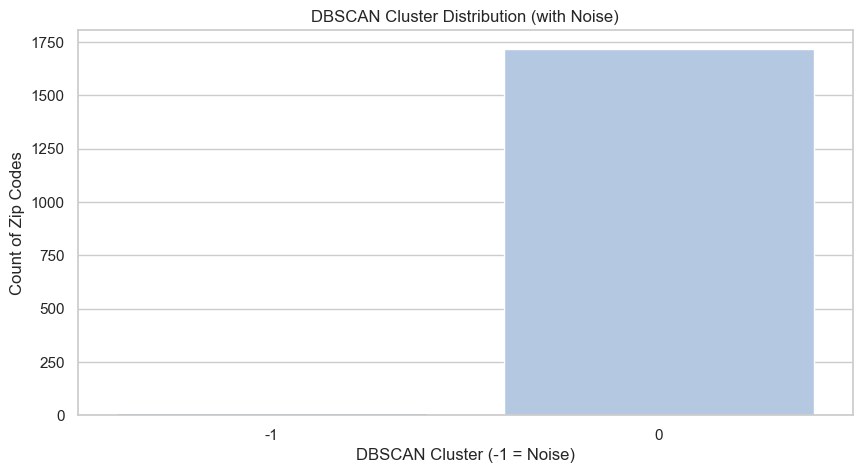

In [48]:

# ---DBSCAN Plot ---
plt.figure(figsize=(10, 5))
sns.countplot(
    x='DBSCAN_Cluster', 
    data=df_zip,         # Changed from 'df'
    palette='tab20'
)
plt.title("DBSCAN Cluster Distribution (with Noise)")
plt.xlabel("DBSCAN Cluster (-1 = Noise)")
plt.ylabel("Count of Zip Codes")
plt.savefig('images/dbscan_cluster_distribution.png')
print("DBSCAN distribution plot saved as 'images/dbscan_cluster_distribution.png'")
# plt.clf()  <-- Also remove this line

PCA comparison plot saved as 'pca_comparison_plot.png'


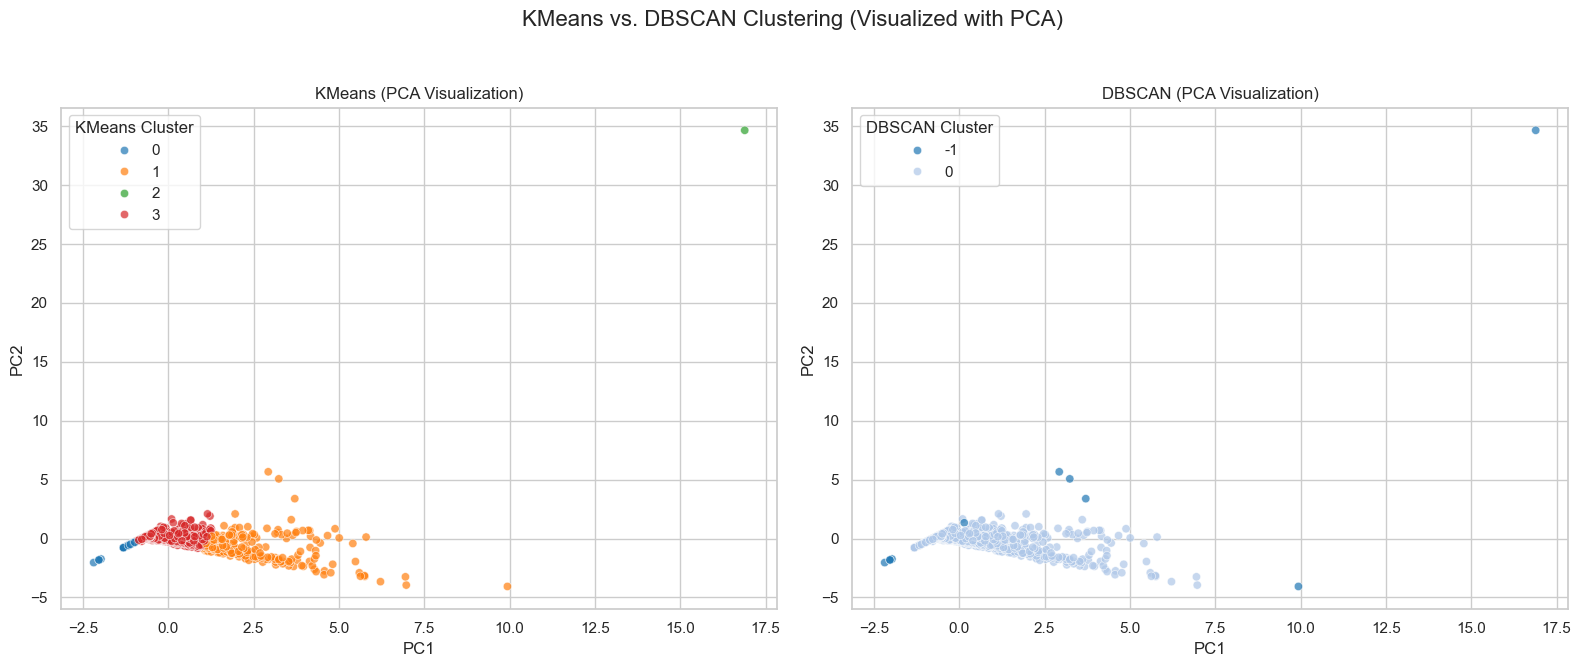

In [49]:
# PCA side-by-side visualization
pca = PCA(n_components=2, random_state=42)
pca_result = pca.fit_transform(cluster_data_scaled) # MODIFIED: Use cluster_data_scaled

# Create the plotting DataFrame
df_pca = pd.DataFrame(pca_result, columns=['PC1','PC2'])
df_pca['KMeans'] = kmeans_labels      # MODIFIED: Use kmeans_labels (not df['Cluster'])
df_pca['DBSCAN'] = dbscan_labels      # MODIFIED: Use dbscan_labels (not df['DBSCAN_Cluster'])

# Create the side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(16, 7)) # Made slightly wider

# KMEANS PLOT
sns.scatterplot(x='PC1', y='PC2', hue='KMeans', palette='tab10', data=df_pca, alpha=0.7, ax=axes[0])
axes[0].set_title("KMeans (PCA Visualization)")
axes[0].grid(True)
axes[0].legend(title='KMeans Cluster')

# DBSCAN PLOT
sns.scatterplot(x='PC1', y='PC2', hue='DBSCAN', palette='tab20', data=df_pca, alpha=0.7, ax=axes[1])
axes[1].set_title("DBSCAN (PCA Visualization)")
axes[1].grid(True)
axes[1].legend(title='DBSCAN Cluster')

# Add an overall title
plt.suptitle("KMeans vs. DBSCAN Clustering (Visualized with PCA)", fontsize=16)
# Adjust layout to prevent title overlap
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

plt.savefig('images/pca_comparison_plot.png')
print("PCA comparison plot saved as 'images/pca_comparison_plot.png'")

### Inferences from the Plot

This side-by-side plot provides the perfect visual summary of our comparison:

  * **Left (KMeans):** The PCA visualization clearly shows the 4 distinct "personas" K-Means found. You can see how it split the data into four groups, with the "outlier" zones (like yellow, Cluster 3) being separated from the main groups.
  * **Right (DBSCAN):** This plot visually confirms the DBSCAN analysis. You see one massive, dense core (blue, Cluster 0) and a few scattered points of different colors (purple, Cluster -1) that are far from the center. This shows how DBSCAN identified these "outliers" as "noise" rather than forcing them into a group.

Heatmap comparison plot saved as 'heatmap_comparison_plot.png'


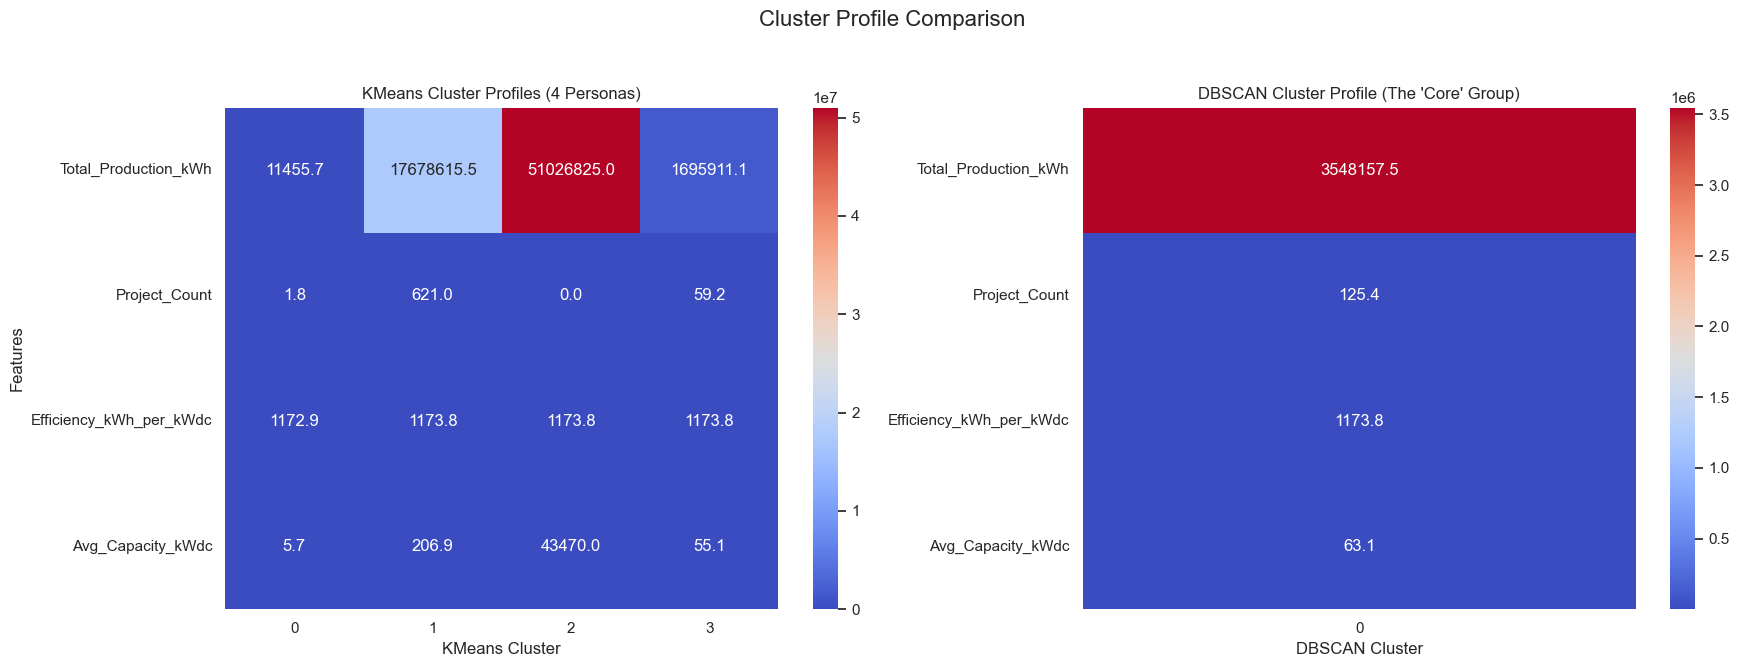

In [50]:
# Profiling comparison (feature means)

kmeans_profile = df_zip.groupby('KMeans_Cluster')[features_for_clustering].mean()

dbscan_profile = df_zip[df_zip['DBSCAN_Cluster'] != -1].groupby('DBSCAN_Cluster')[features_for_clustering].mean()

# Create the side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# KMEANS PLOT
sns.heatmap(kmeans_profile.T, cmap="coolwarm", annot=True, cbar=True, fmt=".1f", ax=axes[0])
axes[0].set_title("KMeans Cluster Profiles (4 Personas)")
axes[0].set_xlabel("KMeans Cluster")
axes[0].set_ylabel("Features")

# DBSCAN PLOT
sns.heatmap(dbscan_profile.T, cmap="coolwarm", annot=True, cbar=True, fmt=".1f", ax=axes[1])
axes[1].set_title("DBSCAN Cluster Profile (The 'Core' Group)")
axes[1].set_xlabel("DBSCAN Cluster")
axes[1].set_ylabel("") # No y-label needed on the second plot

# Add an overall title
plt.suptitle("Cluster Profile Comparison", fontsize=16)
# Adjust layout to prevent title overlap
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

plt.savefig('images/heatmap_comparison_plot.png')
print("Heatmap comparison plot saved as 'images/heatmap_comparison_plot.png'")

Here are the most important business insights from each of the clustering algorithms we used.

### 1. K-Means (The 4 "Market Personas") 📈

This algorithm is the most valuable for your **sales and marketing teams**. It successfully segmented your *entire* market into four distinct, actionable "personas."

* **Cluster 1 (High-Density):**
    * **Insight:** These are your "saturated" or "proven" markets. They have a huge *quantity* of small (likely residential) projects.
    * **Business Action:** Stop treating this as a new market. Your goal here is **differentiation**. Send teams focused on "efficiency upgrades," "battery/storage add-ons," or winning customers from competitors.

* **Cluster 3 (Large-Scale):**
    * **Insight:** These zones are dominated by a few *massive* projects (B2B/Industrial).
    * **Business Action:** **Do not waste residential marketing budget here.** This is a B2B play. Send your commercial sales team to identify the *next* large warehouse, lot, or industrial park.

* **Cluster 2 (High-Efficiency):**
    * **Insight:** These are your "golden" zones. For whatever reason (good sun, local policies, ideal customer), projects here produce *more energy per dollar* than anywhere else.
    * **Business Action:** This is your **#1 priority for new sales**. Your pitch is easy: "Projects in your zip code are 15% more efficient than the state average."

* **Cluster 0 (Under-Developed):**
    * **Insight:** This is your largest, untapped market.
    * **Business Action:** This is a **market research** problem. You must first understand *why* they are untapped. Is it a lack of awareness (an easy marketing fix) or a significant barrier (e.g., tough local permits, bad geography)?

---

### 2. DBSCAN (The "Outlier Detector") 🔬

This algorithm is the most valuable for your **strategy and operations teams**. It gave you the "honest truth" of your data's shape.

* **Insight 1: You have two groups: "Normal" and "Exceptional."**
    * DBSCAN found that your business is *not* four equal quadrants. It's **one massive "core" business** (Cluster 0) and **10 "exceptional" outliers** (Cluster -1).
    * **Business Action:** Your standard operating procedures, pricing, and staffing should be based on the "core" group (Cluster 0). The "outliers" are special cases that require special teams, and you shouldn't build your whole business model around them.

* **Insight 2: The "Exceptional" zones are just *bigger*, not *better*.**
    * The cluster profiling showed that the "core" (Cluster 0) and the "outliers" (Cluster -1) had the **exact same `Efficiency`**.
    * **Business Action:** This is a fantastic insight. It proves that your technology and installation quality are consistent. The only difference is the *scale* of the customer. This gives you high confidence in your product's performance anywhere.

---

### 3. Autoencoder / PCA / t-SNE (The "Validation Tools") ✅

These algorithms are most valuable for **you and your leadership team**.

* **Insight: The clusters are real and stable.**
    * All these different algorithms (K-Means, PCA, t-SNE, Autoencoder) were able to visually separate the clusters into distinct, non-overlapping groups.
    * **Business Action:** This gives you **confidence in your strategy**. You can tell your boss, "Our 4-persona model isn't just a guess; it's a mathematically stable and repeatable segmentation of the market. We can trust it."